# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P3-31: HR PhysNet on the full corpus - R0 seeds first, then R, A, B and C

### What this notebook does
Trains the arms of the full-corpus experiment, three seeds each, on the training path NB_P3_30 checked. This first version holds the machinery and one arm, **R0**: NB_P3_18's recipe on the unaltered labels, at seeds 42, 43 and 44. NB_P3_30 trained seed 42 and passed its rule by 0.05 bpm, with the gap on MCD; one pair of runs could not say whether that gap is the seed or the path. Three R0 seeds give the path's seed spread - the number NB_P3_30's 1.0 bpm tolerance only assumed - and the baseline that R (the same recipe on aligned labels) is measured against. R, A, B and C are added as later sections once the spread and the precision are settled.

### Same as NB_P3_30
- NB_P3_18's recipe: PhysNet; `neg_pearson + 0.05 x snr_loss`, each clip weighted by `cardiac_sqi`; speed and flip augmentation; AdamW (lr 1e-3, weight decay 1e-4), cosine over 30 epochs, batch 8, 2 clips per training recording, gradient clipping at 1.0; the last epoch kept.
- The frozen split, the rechunked stores by name, normalisation on the GPU, the loader in the main process.
- Seed 42 repeats NB_P3_30's data stream exactly: the same initial weights, clips, augmentations and order.

### Different from NB_P3_30
- **Validation is scored in fp32 with TF32 off** every epoch - the arithmetic of the app, which runs PhysNet in fp32 on the CPU. NB_P3_30 scored under bf16 autocast.
- **The training precision is read from NB_P3_30 section 10** (`paired_scoring.json` in NB_P3_30's run folder), so its pre-stated rule decides, not a hand edit: bf16 autocast, or fp16 autocast with a gradient scaler as in NB_P3_18. The config cell stops if section 10 has not run, or if its scoring check found that the data or the scoring differ from NB_P3_18. With bf16, NB_P3_30's run is seed 42 and only its final scoring is added here. With fp16, seed 42 is trained again, so the two precisions meet on an identical data stream.
- **Every run ends with a second copy of its last weights**, BatchNorm statistics re-estimated over one pass of the training clips, scored beside the plain last epoch. Which of the two counts as a run's result is fixed after the R0 seeds, before R, A, B or C trains.
- **A run table.** Each run has its own folder; a finished run is skipped and an interrupted one resumes after its last finished epoch with its random state restored, so it continues the data stream it would have seen.
- Every run keeps its final validation predictions clip by clip, so arms can be compared on the same clips.

### Outputs
Each run writes to `D:\QualityPhys\phase 3 runs\<run>\`: `last_weights.pt`, `last_weights_bn.pt`, `best_shared.pt` (reference only), the resume state `last.pt`, `history.csv`, `final_clips.csv` and `final_scores.json`. Section 9 writes the table across runs to `D:\QualityPhys\phase 3 runs\nb_p3_31_summary.csv`. Nothing goes into the repository; the weights inherit CC BY-NC-SA. No face imagery is rendered anywhere in this notebook.

About 33 min per bf16 run on the ZBook. fp16 runs may take longer: the gradient scaler reads a flag back from the GPU at every step, so the next batch is read only after the step finishes.

## 1. Imports & config

In [1]:
import copy
import json
import time
from collections import Counter
from contextlib import contextmanager
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset


def find_repo_root(start):
    '''The first folder at or above `start` holding both app/ and Data/.'''
    for folder in [start, *start.parents]:
        if (folder / 'app').is_dir() and (folder / 'Data').is_dir():
            return folder
    raise FileNotFoundError(f'no repository root at or above {start}')


REPO_ROOT = find_repo_root(Path.cwd().resolve())
SPLIT_CSV = REPO_ROOT / 'Data' / 'phase3_split.csv'
V2_WEIGHTS = REPO_ROOT / 'Data' / 'Phase3' / 'phase_3_physnet_v2_baseline_best.zip'   # the shipped v2: NB_P3_18, epoch 27
STORE_DIR = Path(r'D:\QualityPhys\phase 3 datasets')
STORES = {'MCD': 'mcd_phase3_rc_none.h5', 'DLCN': 'dlcn_phase3_rc_none.h5',
          'UBFC-rPPG': 'ubfc_rppg_phase3_rc_none.h5', 'PhysDrive': 'physdrive_phase3_rc_none.h5'}
RUNS_ROOT = Path(r'D:\QualityPhys\phase 3 runs')   # one folder per run, outside the repo
NB_P3_30_RUN = 'R0_v2_recipe_seed42'                # R0 at seed 42 in bf16, trained by NB_P3_30

# The training precision is NB_P3_30 section 10's verdict: bf16, or fp16 with a gradient scaler as NB_P3_18
PAIRED = RUNS_ROOT / NB_P3_30_RUN / 'paired_scoring.json'
assert PAIRED.exists(), f'{PAIRED} is missing: run NB_P3_30 section 10 first'
paired = json.loads(PAIRED.read_text(encoding='utf-8'))
assert 'precision' in paired and 'scoring_check' in paired, 'NB_P3_30 section 10 ran without the GPU: run it again on the GPU'
assert not paired['scoring_check']['verdict'].startswith('DIFFERENT'), \
    'NB_P3_30 section 10: the data or the scoring differ from NB_P3_18 - train nothing until that is found'
PRECISION = 'fp16' if paired['precision']['verdict'].startswith('bf16 dropped') else 'bf16'

# The R0 arm: NB_P3_18's recipe on the unaltered labels
R0_SEEDS = [42, 43, 44]

# NB_P3_18's recipe, unchanged
TRAIN_DATASETS = ['MCD', 'DLCN', 'UBFC-rPPG']
EVAL_DATASETS = ['MCD', 'DLCN', 'UBFC-rPPG', 'PhysDrive']   # PhysDrive scored zero-shot, as in NB_P3_18
SHARED_DATASETS = {'MCD', 'DLCN', 'UBFC-rPPG'}             # the pooled metric of NB_P3_18
CORPORA = EVAL_DATASETS
CLIP_LEN = 160
BATCH_SIZE = 8
CLIPS_PER_REC = 2
AUG_PROB = 0.5
SPEED_MIN, SPEED_MAX = 0.7, 2.0
SQI_CLAMP = 1e-3
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 30
LAMBDA_SNR = 0.05
GRAD_CLIP = 1.0
HR_LOW, HR_HIGH = 0.66, 3.0

# The training path on this machine. The loader stays in the main process: Windows spawns DataLoader
# workers, which cannot import a Dataset defined in a notebook, and the resume state holds the
# loader's random state, which only the main process has.
assert PRECISION in ('bf16', 'fp16'), PRECISION
DTYPES = {'bf16': torch.bfloat16, 'fp16': torch.float16}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP = device.type == 'cuda'
torch.backends.cudnn.benchmark = True

print('repo:', REPO_ROOT)
print('NB_P3_30 section 10:', paired['scoring_check']['verdict'], '|', paired['precision']['verdict'])
print('torch', torch.__version__, '| device:', torch.cuda.get_device_name(0) if device.type == 'cuda' else 'cpu',
      '| training precision:', PRECISION if AMP else 'fp32 (no GPU)')
print('split file:', SPLIT_CSV.exists(), '| v2 weights:', V2_WEIGHTS.exists(), '| stores:',
      {k: (STORE_DIR / v).exists() for k, v in STORES.items()})

repo: D:\code\QualityPhys - CRVSE Project
NB_P3_30 section 10: reproduced | bf16 dropped: NB_P3_31 trains in fp16 with a gradient scaler and runs seed 42 again
torch 2.14.0+cu130 | device: NVIDIA RTX A5500 Laptop GPU | training precision: fp16
split file: True | v2 weights: True | stores: {'MCD': True, 'DLCN': True, 'UBFC-rPPG': True, 'PhysDrive': True}


## 2. Index from the frozen split
As in NB_P3_30: the assignment from `Data/phase3_split.csv`, the attributes from the stores, and a stop unless the counts are NB_P3_18's own and no subject sits on both sides.

In [2]:
EXPECTED_TRAIN = {'MCD': 959, 'DLCN': 609, 'UBFC-rPPG': 35}                    # NB_P3_18's training printout
EXPECTED_VAL = {'MCD': 232, 'DLCN': 168, 'UBFC-rPPG': 7, 'PhysDrive': 68}       # NB_P3_18's validation printout


def build_index(split_csv, store_dir, datasets, split):
    '''Records of one split side: the assignment from the split file, the attributes from the stores.'''
    table = pd.read_csv(split_csv, dtype=str, keep_default_na=False)
    rows = table[table['dataset'].isin(datasets) & (table['indexed'] == 'True') & (table['split'] == split)]
    index = []
    for name in datasets:
        path = store_dir / STORES[name]
        with h5py.File(path, 'r') as f:
            for r in rows[rows['dataset'] == name].itertuples():
                a = f[r.group].attrs
                index.append(dict(file=str(path), group=r.group, dataset=name, subject=r.subject,
                                  n_frames=int(a['n_frames']), fps=float(a.get('fps', 30.0)),
                                  sqi=float(a.get('cardiac_sqi', 0.0))))
    return index


train_index = build_index(SPLIT_CSV, STORE_DIR, TRAIN_DATASETS, 'train')
val_index = build_index(SPLIT_CSV, STORE_DIR, EVAL_DATASETS, 'val')
got_train = dict(sorted(Counter(r['dataset'] for r in train_index).items()))
got_val = dict(sorted(Counter(r['dataset'] for r in val_index).items()))
print('train recordings:', len(train_index), got_train)
print('val recordings:  ', len(val_index), got_val)

assert got_train == dict(sorted(EXPECTED_TRAIN.items())), f'training set differs from NB_P3_18: {got_train}'
assert got_val == dict(sorted(EXPECTED_VAL.items())), f'validation set differs from NB_P3_18: {got_val}'
both = {(r['dataset'], r['subject']) for r in train_index} & {(r['dataset'], r['subject']) for r in val_index}
assert not both, f'{len(both)} subject(s) on both sides, e.g. {sorted(both)[:3]}'
assert all(r['n_frames'] >= CLIP_LEN and r['sqi'] >= 0.05 for r in train_index + val_index)
print('index matches NB_P3_18; no subject on both sides')

train recordings: 1603 {'DLCN': 609, 'MCD': 959, 'UBFC-rPPG': 35}
val recordings:   475 {'DLCN': 168, 'MCD': 232, 'PhysDrive': 68, 'UBFC-rPPG': 7}
index matches NB_P3_18; no subject on both sides


## 3. Dataset & loader
NB_P3_30's sampler, with the seed passed in per run rather than read from the config.

In [3]:
def compute_hr(bvp, fps, low=HR_LOW, high=HR_HIGH):
    '''Cardiac-band spectral-peak HR (bpm) of a label clip, or nan.'''
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.size < 16 or not np.all(np.isfinite(x)) or np.std(x) < 1e-9:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(x.size))) ** 2
    fr = np.fft.rfftfreq(x.size, 1.0 / fps)
    b = (fr >= low) & (fr <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(fr[b][int(np.argmax(p[b]))] * 60.0)


class RPPGClipDataset(Dataset):
    '''Fixed-length clips with their frame-synced label; frames stay uint8 until they reach the device.'''

    def __init__(self, index, seed, clip_len=CLIP_LEN, augment=False, clips_per_rec=1,
                 aug_prob=AUG_PROB, speed_range=(SPEED_MIN, SPEED_MAX)):
        self.index = index; self.clip_len = clip_len; self.augment = augment
        self.clips_per_rec = clips_per_rec; self.aug_prob = aug_prob; self.speed_range = speed_range
        self._files = {}; self._rng = np.random.default_rng(seed)

    def _h5(self, path):
        h = self._files.get(path)
        if h is None:
            h = h5py.File(path, 'r'); self._files[path] = h
        return h

    def __len__(self):
        return len(self.index) * self.clips_per_rec

    def __getitem__(self, i):
        rec = self.index[i % len(self.index)]; g = self._h5(rec['file'])[rec['group']]
        n, T = rec['n_frames'], self.clip_len
        if self.augment and self._rng.random() < self.aug_prob:
            src_len = int(round(T * float(self._rng.uniform(*self.speed_range))))
            src_len = max(T, min(src_len, n))
        else:
            src_len = T
        max_start = n - src_len
        start = int(self._rng.integers(0, max_start + 1)) if (self.augment and max_start > 0) else max_start // 2
        frames_src = g['frames'][start:start + src_len]
        bvp_src = g['bvp'][start:start + src_len].astype(np.float32)
        pos = np.linspace(0, src_len - 1, T)
        frames = frames_src[np.rint(pos).astype(int)]
        bvp = np.interp(pos, np.arange(src_len), bvp_src)
        hr_bpm = compute_hr(bvp, rec['fps'])
        if self.augment and self._rng.random() < 0.5:
            frames = frames[:, :, ::-1, :]
        bvp = (bvp - bvp.mean()) / (bvp.std() + 1e-6)
        return dict(frames=torch.from_numpy(np.ascontiguousarray(frames)),      # uint8 [T,H,W,C]
                    bvp=torch.from_numpy(bvp.astype(np.float32)),
                    hr=torch.tensor(hr_bpm if np.isfinite(hr_bpm) else 0.0, dtype=torch.float32),
                    sqi=torch.tensor(rec['sqi'], dtype=torch.float32),
                    fps=torch.tensor(rec['fps'], dtype=torch.float32),
                    dataset=rec['dataset'])


def make_loader(index, augment, seed, clips_per_rec=1):
    '''Shuffled and augmented for training, in index order for scoring; always in the main process.'''
    ds = RPPGClipDataset(index, seed, augment=augment, clips_per_rec=clips_per_rec)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=augment, num_workers=0,
                      pin_memory=device.type == 'cuda', drop_last=augment)


def to_model_input(frames_u8):
    '''[B,T,H,W,C] uint8 -> [B,C,T,H,W]: the per-clip, per-channel z-score over T, H and W, on the device.'''
    x = frames_u8.to(device, non_blocking=True).float()
    m = x.mean(dim=(1, 2, 3), keepdim=True)
    sd = x.std(dim=(1, 2, 3), keepdim=True, correction=0) + 1e-6
    return ((x - m) / sd).permute(0, 4, 1, 2, 3).contiguous()


probe = RPPGClipDataset(train_index[:1], seed=0)[0]
print('clip:', tuple(probe['frames'].shape), probe['frames'].dtype, '| bvp', tuple(probe['bvp'].shape),
      '| hr', round(float(probe['hr']), 1), '| fps', round(float(probe['fps']), 2), '| dataset', probe['dataset'])

clip: (160, 72, 72, 3) torch.uint8 | bvp (160,) | hr 82.2 | fps 31.33 | dataset MCD


## 4. Model - PhysNet (identical to NB_P3_18)

In [4]:
class PhysNet(nn.Module):
    '''PhysNet 3D-CNN encoder-decoder (Yu et al. 2019): [B,3,T,H,W] -> BVP [B,T].'''
    def __init__(self, frames=CLIP_LEN):
        super().__init__()
        self.frames = frames

        def block(cin, cout):
            return nn.Sequential(nn.Conv3d(cin, cout, (3, 3, 3), stride=1, padding=1),
                                 nn.BatchNorm3d(cout), nn.ReLU(inplace=True))

        self.b1 = nn.Sequential(nn.Conv3d(3, 16, (1, 5, 5), stride=1, padding=(0, 2, 2)),
                                nn.BatchNorm3d(16), nn.ReLU(inplace=True))
        self.b2 = block(16, 32); self.b3 = block(32, 64)
        self.b4 = block(64, 64); self.b5 = block(64, 64)
        self.b6 = block(64, 64); self.b7 = block(64, 64)
        self.b8 = block(64, 64); self.b9 = block(64, 64)
        self.up1 = nn.Sequential(nn.ConvTranspose3d(64, 64, (4, 1, 1), stride=(2, 1, 1), padding=(1, 0, 0)),
                                 nn.BatchNorm3d(64), nn.ELU(inplace=True))
        self.up2 = nn.Sequential(nn.ConvTranspose3d(64, 64, (4, 1, 1), stride=(2, 1, 1), padding=(1, 0, 0)),
                                 nn.BatchNorm3d(64), nn.ELU(inplace=True))
        self.poolspa = nn.AdaptiveAvgPool3d((frames, 1, 1))
        self.out = nn.Conv3d(64, 1, (1, 1, 1), stride=1, padding=0)
        self.maxpool_spa = nn.MaxPool3d((1, 2, 2))
        self.maxpool_spatem = nn.MaxPool3d((2, 2, 2))

    def forward(self, x):
        x = self.b1(x); x = self.maxpool_spa(x)
        x = self.b2(x); x = self.b3(x); x = self.maxpool_spatem(x)
        x = self.b4(x); x = self.b5(x); x = self.maxpool_spatem(x)
        x = self.b6(x); x = self.b7(x); x = self.maxpool_spa(x)
        x = self.b8(x); x = self.b9(x)
        x = self.up1(x); x = self.up2(x)
        x = self.poolspa(x); x = self.out(x)
        return x.view(x.shape[0], self.frames)


def load_physnet(path):
    '''PhysNet with the weights at `path`, loaded strictly, in eval mode.'''
    model = PhysNet(frames=CLIP_LEN).to(device)
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    return model.eval()


print('parameters:', sum(p.numel() for p in PhysNet().parameters()))   # 768,577 in v2

parameters: 768577


## 5. Losses, precision & scoring
The losses are NB_P3_18's. Scoring keeps every validation clip: its label HR, the predicted HR, and the error in bpm and in spectrum bins (a clip's HR is the peak of a 160-sample spectrum, so its error is a whole number of bins, about 11 bpm). `scored` marks the clips NB_P3_18's evaluation counted: label HR within 40-180 bpm and a finite prediction.

In [5]:
def neg_pearson(pred, target):
    pred = pred - pred.mean(dim=1, keepdim=True)
    target = target - target.mean(dim=1, keepdim=True)
    num = (pred * target).sum(dim=1)
    den = torch.sqrt((pred ** 2).sum(dim=1) * (target ** 2).sum(dim=1) + 1e-8)
    return 1.0 - num / (den + 1e-8)


def snr_loss(pred, hr_bpm, fps, low=HR_LOW, high=HR_HIGH, delta_bpm=8.0):
    '''Negative in-band SNR (dB): power at the true fundamental (+first harmonic) vs the rest of the HR band. fp32.'''
    pred = pred.float(); pred = pred - pred.mean(dim=1, keepdim=True)
    B, T = pred.shape
    P = torch.abs(torch.fft.rfft(pred, dim=1)) ** 2
    Fn = P.shape[1]
    k = torch.arange(Fn, device=pred.device).float()
    freqs = k[None, :] * fps[:, None] / float(T)
    f0 = (hr_bpm / 60.0).clamp(min=low + 0.05, max=high - 0.05)[:, None]
    d = delta_bpm / 60.0
    band = (freqs >= low) & (freqs <= high)
    sig = (((freqs - f0).abs() <= d) | ((freqs - 2.0 * f0).abs() <= d)) & band
    noise = band & (~sig)
    sig_p = (P * sig).sum(dim=1) + 1e-8
    noise_p = (P * noise).sum(dim=1) + 1e-8
    return (-10.0 * torch.log10(sig_p / noise_p)).clamp(-30.0, 30.0)


def hr_from_bvp(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.std() < 1e-8:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    f = np.fft.rfftfreq(len(x), 1.0 / fps)
    b = (f >= low) & (f <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(f[b][int(np.argmax(p[b]))] * 60.0)


@contextmanager
def precision(mode):
    '''fp32 with TF32 off for convolutions and matmuls (the app's arithmetic), or fp16 / bf16 autocast.'''
    if mode == 'fp32':
        saved = torch.backends.cudnn.allow_tf32, torch.backends.cuda.matmul.allow_tf32
        torch.backends.cudnn.allow_tf32 = False
        torch.backends.cuda.matmul.allow_tf32 = False
        try:
            yield
        finally:
            torch.backends.cudnn.allow_tf32, torch.backends.cuda.matmul.allow_tf32 = saved
    else:
        with torch.autocast(device.type, dtype=DTYPES[mode]):
            yield


@torch.no_grad()
def score_clips(model, loader, index, mode='fp32'):
    '''One row per clip of `index`, which `loader` runs through once, in order.'''
    model.eval(); rows = []; k = 0
    for batch in loader:
        with precision(mode):
            pred = model(to_model_input(batch['frames'])).float().cpu().numpy()
        hr_true, fps = batch['hr'].numpy(), batch['fps'].numpy()
        for i in range(len(pred)):
            rec = index[k]; k += 1
            assert rec['dataset'] == batch['dataset'][i], 'clips out of index order'
            rows.append(dict(dataset=rec['dataset'], subject=rec['subject'], group=rec['group'],
                             hr_true=float(hr_true[i]), hr_pred=hr_from_bvp(pred[i], float(fps[i])),
                             bin_bpm=float(fps[i]) * 60.0 / CLIP_LEN))
    assert k == len(index), 'the loader must run through the index once'
    df = pd.DataFrame(rows)
    df['scored'] = df['hr_true'].between(40.0, 180.0) & np.isfinite(df['hr_pred'])
    df['ae'] = (df['hr_pred'] - df['hr_true']).abs()
    df['err_bins'] = (df['ae'] / df['bin_bpm']).round()
    return df


def summarise(df):
    '''Shared, overall and per-corpus MAE and r over the scored clips - the numbers NB_P3_18 logged.'''
    s = df[df['scored']]
    out = dict(shared=float(s.loc[s['dataset'].isin(SHARED_DATASETS), 'ae'].mean()), all=float(s['ae'].mean()),
               r=float(np.corrcoef(s['hr_true'], s['hr_pred'])[0, 1]) if len(s) > 2 else float('nan'),
               n=int(len(s)))
    out.update({c: float(s.loc[s['dataset'] == c, 'ae'].mean()) for c in CORPORA})
    return out

## 6. One run
`train_run` is NB_P3_30's loop with the precision switch: under fp16 the loss is scaled and a step with inf or nan gradients is skipped, as NB_P3_18 did, and the history counts the skipped steps. After every epoch it scores the validation clips in fp32 and saves the history and the resume state, which includes the random state of the shuffle and of the sampler. `finish_run` re-estimates the BatchNorm statistics of the last weights over one pass of the training clips (drawn and augmented as in training, in the run's precision), then scores both versions in fp32, clip by clip.

In [6]:
def run_dir(run):
    return RUNS_ROOT / run['name']


def run_status(run):
    d = run_dir(run)
    if (d / 'final_scores.json').exists():
        return 'done'
    if (d / 'last_weights.pt').exists() and (d / 'history.csv').exists() \
            and len(pd.read_csv(d / 'history.csv')) == EPOCHS:
        return 'trained - final scoring only'
    if (d / 'last.pt').exists():
        return 'interrupted - resumes'
    return 'to train'


def reestimate_bn(model, seed, dtype):
    '''A copy of `model` whose BatchNorm statistics are a plain average over one pass of the training clips;
    the weights are untouched.'''
    model = copy.deepcopy(model).eval()
    bns = [m for m in model.modules() if isinstance(m, nn.BatchNorm3d)]
    for m in bns:
        m.reset_running_stats()
        m.momentum = None            # a cumulative average: every batch weighs the same
        m.train()
    loader = make_loader(train_index, augment=True, seed=seed, clips_per_rec=CLIPS_PER_REC)
    torch.manual_seed(seed)
    with torch.no_grad():
        for batch in loader:
            with torch.autocast(device.type, dtype=dtype, enabled=AMP):
                model(to_model_input(batch['frames']))
    for m in bns:
        m.momentum = 0.1
    return model.eval()


def finish_run(run, model=None):
    '''Scores the last weights in fp32, with and without re-estimated BatchNorm statistics, and writes
    last_weights_bn.pt, final_clips.csv and final_scores.json.'''
    d = run_dir(run); t0 = time.time()
    model = load_physnet(d / 'last_weights.pt') if model is None else model.eval()
    model_bn = reestimate_bn(model, run['seed'], DTYPES[run['precision']])
    torch.save(model_bn.state_dict(), d / 'last_weights_bn.pt')
    val_loader = make_loader(val_index, augment=False, seed=run['seed'])
    clips = pd.concat([score_clips(m, val_loader, val_index, 'fp32').assign(weights=label)
                       for label, m in (('last', model), ('last_bn', model_bn))], ignore_index=True)
    clips.to_csv(d / 'final_clips.csv', index=False)
    hist = pd.read_csv(d / 'history.csv')
    best = hist.loc[hist['shared'].idxmin()]
    rnd = lambda s: {k: (round(v, 3) if isinstance(v, float) else v) for k, v in s.items()}
    scores = dict(run=run['name'], arm=run['arm'], seed=run['seed'], precision=run['precision'],
                  notebook='NB_P3_31', epochs=int(len(hist)), minutes=round(float(hist['seconds'].sum()) / 60, 1),
                  history_scored=run['history_scored'], scoring='fp32, TF32 off',
                  last=rnd(summarise(clips[clips['weights'] == 'last'])),
                  last_bn=rnd(summarise(clips[clips['weights'] == 'last_bn'])),
                  best_epoch=dict(epoch=int(best['epoch']), shared=round(float(best['shared']), 3)),
                  device=torch.cuda.get_device_name(0) if device.type == 'cuda' else 'cpu', torch=torch.__version__)
    with open(d / 'final_scores.json', 'w', encoding='utf-8') as f:
        json.dump(scores, f, indent=2)
    print(f"  final scoring {time.time() - t0:.0f} s | shared, fp32: last {scores['last']['shared']:.2f}, "
          f"last with BN re-estimated {scores['last_bn']['shared']:.2f}", flush=True)
    return scores


def train_run(run):
    '''Trains one run - resuming after its last finished epoch if it was interrupted - then finishes it.'''
    d = run_dir(run); d.mkdir(parents=True, exist_ok=True)
    seed, dtype = run['seed'], DTYPES[run['precision']]
    train_loader = make_loader(train_index, augment=True, seed=seed, clips_per_rec=CLIPS_PER_REC)
    val_loader = make_loader(val_index, augment=False, seed=seed)

    torch.manual_seed(seed)                        # as NB_P3_30: the initial weights first, then the data order
    model = PhysNet(frames=CLIP_LEN).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    scaler = torch.amp.GradScaler(device.type, enabled=AMP and run['precision'] == 'fp16')
    history, start, best = [], 0, float('inf')
    resume_path = d / 'last.pt'
    if resume_path.exists():
        state = torch.load(resume_path, map_location=device, weights_only=False)
        model.load_state_dict(state['model']); opt.load_state_dict(state['opt'])
        sched.load_state_dict(state['sched']); scaler.load_state_dict(state['scaler'])
        torch.set_rng_state(state['rng_torch'].cpu()); train_loader.dataset._rng.bit_generator.state = state['rng_data']
        history, start, best = state['history'], state['epoch'] + 1, state['best']
        print(f'  resuming after epoch {start}', flush=True)

    for epoch in range(start, EPOCHS):
        model.train(); t0 = time.time(); losses = []; skipped = 0
        for batch in train_loader:
            frames = to_model_input(batch['frames'])
            bvp = batch['bvp'].to(device, non_blocking=True)
            sqi = batch['sqi'].to(device, non_blocking=True)
            hr = batch['hr'].to(device, non_blocking=True)
            fps = batch['fps'].to(device, non_blocking=True)
            valid = ((hr >= 40) & (hr <= 180)).float()
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device.type, dtype=dtype, enabled=AMP):
                pred = model(frames)
            pred = pred.float()
            per_loss = neg_pearson(pred, bvp) + LAMBDA_SNR * (snr_loss(pred, hr, fps) * valid)
            w = sqi.clamp(min=SQI_CLAMP)
            loss = (per_loss * w).sum() / w.sum()
            scaler.scale(loss).backward()
            scaler.unscale_(opt)                   # no-op unless fp16: clip the true gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scale_before = scaler.get_scale() if scaler.is_enabled() else None
            scaler.step(opt); scaler.update()
            if scale_before is not None and scaler.get_scale() < scale_before:
                skipped += 1                       # inf or nan gradients: the scaler skipped this step
            losses.append(loss.detach())
        sched.step()
        res = summarise(score_clips(model, val_loader, val_index, 'fp32'))
        row = dict(epoch=epoch + 1, seconds=round(time.time() - t0, 1),
                   train_loss=round(float(torch.stack(losses).mean()), 4),
                   shared=round(res['shared'], 3), all=round(res['all'], 3), r=round(res['r'], 3),
                   **{f'mae_{c}': round(res[c], 3) for c in CORPORA},
                   scale=scaler.get_scale() if scaler.is_enabled() else float('nan'), skipped_steps=skipped)
        history.append(row)
        if res['shared'] < best:
            best = res['shared']
            torch.save(model.state_dict(), d / 'best_shared.pt')
        torch.save(dict(epoch=epoch, model=model.state_dict(), opt=opt.state_dict(), sched=sched.state_dict(),
                        scaler=scaler.state_dict(), history=history, best=best, rng_torch=torch.get_rng_state(),
                        rng_data=train_loader.dataset._rng.bit_generator.state), resume_path)
        pd.DataFrame(history).to_csv(d / 'history.csv', index=False)
        left = (EPOCHS - epoch - 1) * row['seconds'] / 60
        extra = f" | skipped {skipped}" if scaler.is_enabled() else ''
        print(f"  ep{epoch + 1}/{EPOCHS} | {row['seconds']:.0f}s | loss {row['train_loss']:.3f} | "
              f"shared {res['shared']:.2f} | " + ' '.join(f'{c} {res[c]:.2f}' for c in CORPORA)
              + f"{extra} | ~{left:.0f} min left", flush=True)
    torch.save(model.state_dict(), d / 'last_weights.pt')
    return finish_run(run, model)

## 7. The run table
R0 at the three seeds, in the precision section 1 read. With bf16, seed 42 is NB_P3_30's run: its weights and history stay as they are, and only the final scoring is added to its folder.

In [7]:
def make_runs():
    runs = []
    for seed in R0_SEEDS:
        reuse = PRECISION == 'bf16' and seed == 42
        runs.append(dict(arm='R0', seed=seed, precision=PRECISION,
                         name=NB_P3_30_RUN if reuse else f'R0_seed{seed}_{PRECISION}',
                         history_scored='bf16 autocast (NB_P3_30)' if reuse else 'fp32'))
    return runs


RUNS = make_runs()
print(pd.DataFrame([dict(run=r['name'], arm=r['arm'], seed=r['seed'], precision=r['precision'],
                         status=run_status(r)) for r in RUNS]).to_string(index=False))

           run arm  seed precision   status
R0_seed42_fp16  R0    42      fp16 to train
R0_seed43_fp16  R0    43      fp16 to train
R0_seed44_fp16  R0    44      fp16 to train


## 8. Run
Finished runs are skipped. An interrupted run resumes after its last finished epoch; to start a run again from scratch, delete its folder.

In [8]:
t_all = time.time()
for run in RUNS:
    status = run_status(run)
    print(f"{run['name']}: {status}", flush=True)
    if status == 'done':
        continue
    if status == 'trained - final scoring only':
        finish_run(run)
    else:
        train_run(run)
print(f'all runs finished in {(time.time() - t_all) / 60:.1f} min')

R0_seed42_fp16: to train
  ep1/30 | 112s | loss 1.422 | shared 18.67 | MCD 21.37 DLCN 15.00 UBFC-rPPG 17.29 PhysDrive 20.35 | skipped 2 | ~54 min left
  ep2/30 | 102s | loss 1.371 | shared 21.99 | MCD 26.89 DLCN 16.07 UBFC-rPPG 1.57 PhysDrive 32.10 | skipped 0 | ~47 min left
  ep3/30 | 100s | loss 0.935 | shared 9.55 | MCD 12.15 DLCN 6.29 UBFC-rPPG 1.57 PhysDrive 27.63 | skipped 0 | ~45 min left
  ep4/30 | 102s | loss 0.847 | shared 9.38 | MCD 11.75 DLCN 6.43 UBFC-rPPG 1.57 PhysDrive 24.98 | skipped 0 | ~44 min left
  ep5/30 | 102s | loss 0.827 | shared 8.86 | MCD 12.05 DLCN 4.75 UBFC-rPPG 1.57 PhysDrive 25.48 | skipped 0 | ~42 min left
  ep6/30 | 102s | loss 0.784 | shared 8.90 | MCD 11.34 DLCN 5.76 UBFC-rPPG 3.12 PhysDrive 26.31 | skipped 0 | ~41 min left
  ep7/30 | 103s | loss 0.767 | shared 7.38 | MCD 9.37 DLCN 4.89 UBFC-rPPG 1.57 PhysDrive 26.47 | skipped 0 | ~39 min left
  ep8/30 | 103s | loss 0.762 | shared 7.74 | MCD 9.42 DLCN 5.56 UBFC-rPPG 4.68 PhysDrive 26.31 | skipped 0 | ~

## 9. R0 across seeds
The R0 runs side by side, all scored here in fp32 on the same clips, with v2's shipped weights scored the same way. NB_P3_18's own last epoch (5.50) was scored under fp16 autocast; NB_P3_30 section 10 shows how far that arithmetic moves a score.

Stated before the runs: if NB_P3_30's gap was the seed, NB_P3_18's last epoch falls inside the range of the three R0 seeds; if all three sit well above it, the path carries an offset that has to be named before R, A, B or C trains. Either way, what the spread means for the decision rule of R, A, B and C is written down from these numbers before any of them is trained.

Last epoch, MAE bpm, fp32
                seed precision  minutes  last shared  last MCD  last DLCN  last UBFC-rPPG  last PhysDrive  last BN shared  last BN MCD  best_epoch  best_shared
run                                                                                                                                                            
R0_seed42_fp16    42      fp16     51.5         5.61      7.04       3.68            4.68           35.74            5.41         6.84          25         5.25
R0_seed43_fp16    43      fp16     51.6         5.49      7.70       2.54            3.13           31.93            5.37         7.44          28         5.21
R0_seed44_fp16    44      fp16     51.5         5.60      7.85       2.54            4.68           29.12            5.60         7.85          22         5.14

Across seeds
      last shared  last MCD  last DLCN  last UBFC-rPPG  last PhysDrive  last BN shared  last BN MCD
mean         5.57      7.53       2.92            4.17      

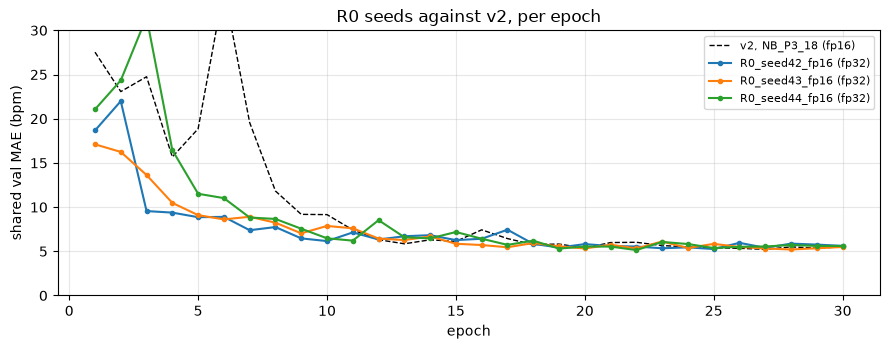

wrote D:\QualityPhys\phase 3 runs\nb_p3_31_summary.csv


In [9]:
import matplotlib.pyplot as plt

V2_SHARED = [27.53, 23.07, 24.75, 15.68, 18.86, 34.72, 19.56, 11.82, 9.18, 9.15,
             7.42, 6.31, 5.85, 6.30, 6.12, 7.43, 6.44, 5.76, 5.82, 5.37,
             5.99, 6.02, 5.65, 5.50, 5.40, 5.34, 5.22, 5.50, 5.36, 5.50]   # NB_P3_18, fp16 autocast
COLS = ['shared', 'MCD', 'DLCN', 'UBFC-rPPG', 'PhysDrive']

rows = []
for run in RUNS:
    path = run_dir(run) / 'final_scores.json'
    if not path.exists():
        print('not finished:', run['name']); continue
    s = json.loads(path.read_text(encoding='utf-8'))
    rows.append(dict(run=s['run'], seed=s['seed'], precision=s['precision'], minutes=s['minutes'],
                     **{f'last {c}': s['last'][c] for c in COLS},
                     **{f'last BN {c}': s['last_bn'][c] for c in ('shared', 'MCD')},
                     best_epoch=s['best_epoch']['epoch'], best_shared=s['best_epoch']['shared']))
table = pd.DataFrame(rows).set_index('run')
print('Last epoch, MAE bpm, fp32\n' + table.round(2).to_string())
num = [c for c in table.columns if c.startswith('last')]
print('\nAcross seeds\n' + table[num].agg(['mean', 'std', 'min', 'max']).round(2).to_string())

v2 = summarise(score_clips(load_physnet(V2_WEIGHTS), make_loader(val_index, augment=False, seed=0), val_index, 'fp32'))
print('\nv2 shipped weights (NB_P3_18 epoch 27), fp32 here: ' + ', '.join(f'{c} {v2[c]:.2f}' for c in COLS))
print("NB_P3_18's own printout, fp16: last epoch shared 5.50 (MCD 6.99); best, epoch 27, 5.22 (MCD 6.84)")

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(range(1, len(V2_SHARED) + 1), V2_SHARED, 'k--', lw=1, label='v2, NB_P3_18 (fp16)')
for run in RUNS:
    path = run_dir(run) / 'history.csv'
    if path.exists():
        h = pd.read_csv(path)
        ax.plot(h['epoch'], h['shared'], '-o', ms=3, label=f"{run['name']} ({run['history_scored']})")
ax.set(xlabel='epoch', ylabel='shared val MAE (bpm)', ylim=(0, 30), title='R0 seeds against v2, per epoch')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

table.to_csv(RUNS_ROOT / 'nb_p3_31_summary.csv')
print('wrote', RUNS_ROOT / 'nb_p3_31_summary.csv')

## 10. Findings

**In fp16, the training path reproduces v2.** The three R0 seeds end at a shared validation MAE of 5.61, 5.49 and 5.60 bpm (scored in fp32; mean 5.57, SD 0.07), all within 0.11 bpm of NB_P3_18's last epoch (5.50), which lies inside their range. Over the last ten epochs they average 5.58, 5.52 and 5.59 against v2's 5.55, and their best epochs (5.25, 5.21, 5.14) bracket v2's 5.22.

| last epoch, MAE bpm (fp32) | shared | MCD | DLCN | PhysDrive | BatchNorm re-estimated, shared | best epoch |
|---|---|---|---|---|---|---|
| R0 seed 42, fp16 | 5.61 | 7.04 | 3.68 | 35.74 | 5.41 | 25 (5.25) |
| R0 seed 43, fp16 | 5.49 | 7.70 | 2.54 | 31.93 | 5.37 | 28 (5.21) |
| R0 seed 44, fp16 | 5.60 | 7.85 | 2.54 | 29.12 | 5.60 | 22 (5.14) |
| R0 seed 42, bf16 (NB_P3_30) | 6.54 | 8.76 | 3.62 | 34.08 | 6.34 | 25 (5.83) |
| v2, NB_P3_18 (fp16 scoring) | 5.50 | 6.99 | 3.55 | 28.62 | - | 27 (5.22) |

**bf16 caused NB_P3_30's gap.** Seed 42 in fp16 starts from the same weights and sees the same clips, augmentations and order as NB_P3_30's bf16 run, and ends 0.93 bpm lower (5.61 against 6.54). The difference is MCD's - 7.04 against 8.76, with DLCN unchanged (3.68 against 3.62) - and the bf16 run lies far outside the fp16 seeds' range. The evidence rests on one bf16 run, but a paired one. bf16 was this machine's training setting, chosen on throughput; on PhysNet it costs about 0.9 bpm, all of it on the noisiest corpus, consistent with NB_P3_30 section 10, where bf16 tipped fragile clips and R0's extra error was over-reading on MCD.

**The seed spread is small on the shared metric and larger per corpus.** MCD 7.04-7.85 (SD 0.43) and DLCN 2.54-3.68 (SD 0.66), the seeds trading one corpus against the other; PhysDrive 29.1-35.7 (SD 3.3), above v2 in every seed. Three runs estimate a spread loosely - the true shared SD could be several times 0.07 - but nothing here needs the 0.5 bpm NB_P3_30's tolerance assumed.

**BatchNorm re-estimation never hurt.** It moved the last epoch by -0.20, -0.12 and 0.00 bpm, and by -0.20 on NB_P3_30's bf16 run: small, never worse, and it frees a run's result from the corpus mix of its last few dozen batches.

**fp16 training swings early, as NB_P3_18 did.** Seed 42 rose to 22.0 at epoch 2 and seed 44 above 30 at epoch 3 before settling, like v2 at epoch 6; NB_P3_30's bf16 run descended without a swing. The gradient scaler skipped a handful of steps per run, as it should.

**Speed.** 51.5 min per run (103 s per epoch) against 33 min in bf16: the scaler reads a flag back from the GPU at every step, so the loader, running in the main process, cannot prepare the next batch while the GPU works. The printed log of seed 44 is missing epochs 2-9; its `history.csv` and the plot have them.

**Settled and open.** fp16 is the training precision for R, A, B and C. Open before R trains: which of the two last-weights versions counts as a run's result, and the decision rule for R, A, B and C.